In [2]:
!nvidia-smi

Sun Sep 14 13:53:47 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.64.01              Driver Version: 576.88         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:02:00.0 Off |                  N/A |
|  0%   45C    P8             17W /  575W |       0MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
import transformers
from datasets import load_dataset
import datasets as hf_datasets
from unsloth import FastLanguageModel
from peft import get_peft_model, LoraConfig, TaskType
import bitsandbytes as bnb
from fastprogress import progress_bar as pb
import matplotlib.pyplot as plt

/tmp/ipykernel_2705085/3521801710.py:7: UserWarning: WARNING: Unsloth should be imported before transformers to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## Configs

In [2]:
device = 'cuda'

N_EPOCHS = 10
TRAIN_BATCH_SIZE = TEST_BATCH_SIZE = 4
LR = 1e-4
WEIGHT_DECAY = 1e-2

USE_AMP = True
AMP_DTYPE = torch.bfloat16

TEXT_PADDING_MAX_LENGTH = 500

## Model & Tokenizer

In [3]:
max_seq_length = 1024
dtype = None

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
# fourbit_models = [
#     "unsloth/gpt-oss-20b-unsloth-bnb-4bit", # 20B model using bitsandbytes 4bit quantization
#     "unsloth/gpt-oss-120b-unsloth-bnb-4bit",
#     "unsloth/gpt-oss-20b", # 20B model using MXFP4 format
#     "unsloth/gpt-oss-120b",
# ] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    # model_name = "unsloth/gpt-oss-20b",
    model_name = "unsloth/gpt-oss-20b-unsloth-bnb-4bit",
    dtype = dtype, # None for auto detection
    max_seq_length = max_seq_length, # Choose any for long context!
    load_in_4bit = True,  # 4 bit quantization to reduce memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
    # token = "hf_...", # use one if using gated models
    use_gradient_checkpointing=False,
)

==((====))==  Unsloth 2025.8.9: Fast Gpt_Oss patching. Transformers: 4.55.4.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.842 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu129. CUDA: 12.0. CUDA Toolkit: 12.9. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Gpt_Oss does not support SDPA - switching to eager!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [4]:
next(model.parameters()).dtype, tokenizer.padding_side

(torch.bfloat16, 'left')

In [5]:
peft_config = LoraConfig(
    r=16,  # Rank
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, peft_config)

model.print_trainable_parameters()

trainable params: 5,283,840 || all params: 20,920,041,024 || trainable%: 0.0253


In [32]:
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): GptOssForCausalLM(
      (model): GptOssModel(
        (embed_tokens): Embedding(201088, 2880, padding_idx=199999)
        (layers): ModuleList(
          (0-23): 24 x GptOssDecoderLayer(
            (self_attn): GptOssAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2880, out_features=4096, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2880, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
    

## Data Preparation

In [6]:
df_news = pd.read_parquet('/mnt/c/data/finance/news/gnews_231116_241123_preprocessed.parquet')

In [7]:
df_news['label'] = LabelEncoder().fit_transform(df_news['topic'])

In [8]:
df_news_sampled = df_news.sample(1000)
df_news_oos_sampled = df_news.loc[~df_news.index.isin(df_news_sampled.index)].sample(100)

In [9]:
df_news_sampled['topic'].value_counts()

topic
NATION_EN        121
BUSSINESS        113
SPORTS           112
ENTERTAINMENT    111
POLICTICS_EN     104
BUSSINESS_EN      95
NATION            91
POLICTICS         77
WORLD_EN          61
TECHNOLOGY        58
WORLD             57
Name: count, dtype: int64

In [10]:
def create_conversation(news: str, topic: str):
    conversation = [
        {
            'role': 'user',
            'content': f'以下のニュースのカテゴリを教えてください。カテゴリ名のみ答えてそれ以外は出力しないでください。\nニュース：{news}'
        },
        {
            'role': 'assistant',
            'content': f"カテゴリ：{topic.replace('_', ' ').lower()}"
        }
    ]
    return conversation

In [11]:
df_news_sampled['coversations'] = df_news_sampled.apply(lambda sr: create_conversation(news=sr['summary'], topic=sr['topic']), axis=1)

In [12]:
df_news_sampled['text'] = df_news_sampled['coversations'].map(
    lambda c: tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=False)
)
df_news_sampled['prompt'] = df_news_sampled['coversations'].map(
    lambda c: tokenizer.apply_chat_template(c[:-1], tokenize=False, add_generation_prompt=True)
)

In [13]:
print(df_news_sampled['text'].iloc[0])

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-14

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.
Calls to these tools must go to the commentary channel: 'functions'.<|end|><|start|>user<|message|>以下のニュースのカテゴリを教えてください。カテゴリ名のみ答えてそれ以外は出力しないでください。
ニュース：Atlantic City Mayor Accused of Beating and Punching His Teenage Daughter  The New York TimesAtlantic City Mayor Marty Small, superintendent wife La'Quetta Small charged with abusing teen daughter  WPVI-TVAtlantic City mayor, wife charged with abusing and assaulting teenage daughter  Yahoo! VoicesAtlantic City Mayor, Superintendent Abused Teen Daughter: Prosecutor  PatchAC Mayor, wife accused of physically, emotionally abusing teen daughter  NBC Philadelphia<|end|><|start|>assistant<|message|>カテゴリ：nation en<|return|>


In [14]:
print(df_news_sampled['prompt'].iloc[0])

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-14

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.
Calls to these tools must go to the commentary channel: 'functions'.<|end|><|start|>user<|message|>以下のニュースのカテゴリを教えてください。カテゴリ名のみ答えてそれ以外は出力しないでください。
ニュース：Atlantic City Mayor Accused of Beating and Punching His Teenage Daughter  The New York TimesAtlantic City Mayor Marty Small, superintendent wife La'Quetta Small charged with abusing teen daughter  WPVI-TVAtlantic City mayor, wife charged with abusing and assaulting teenage daughter  Yahoo! VoicesAtlantic City Mayor, Superintendent Abused Teen Daughter: Prosecutor  PatchAC Mayor, wife accused of physically, emotionally abusing teen daughter  NBC Philadelphia<|end|><|start|>assistant


In [15]:
sr_token_length = df_news_sampled['text'].map(lambda x: tokenizer.encode(x, return_tensors="pt").shape[-1])
sr_char_length = df_news_sampled['text'].map(len)

<Axes: ylabel='Frequency'>

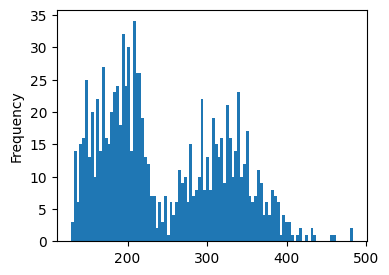

In [16]:
sr_token_length.plot.hist(bins=100, figsize=(4, 3))

<Axes: ylabel='Frequency'>

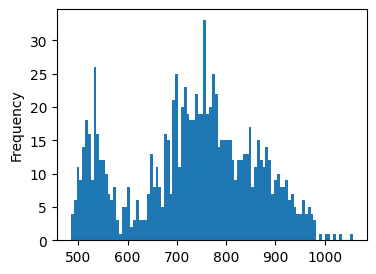

In [17]:
sr_char_length.plot.hist(bins=100, figsize=(4, 3))

In [18]:
hfds_news_sampled = hf_datasets.Dataset.from_pandas(df_news_sampled)

In [19]:
tokenizer.encode('assistant')

[173781]

In [20]:
def prepare_celoss_inputs_leftpad(
    logits: torch.Tensor,
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    response_token_id: int = tokenizer.encode('assistant')[0],
    loss_mask_start_pos_offset = 2,
    ignore_index = -100,
):
    """
    Prepares inputs for left-padded causal language modeling (next-token prediction) loss
    with masking applied only after the first occurrence of a response token (e.g., <|assistant|>).

    This function:
    - Shifts logits and labels for next-token prediction.
    - Applies masking to compute loss only from the assistant's response portion.
    - Handles left-padded sequences (e.g., tokenizer.padding_side = 'left').

    Args:
        logits (torch.Tensor): Raw model output logits of shape [B, T, V].
        input_ids (torch.Tensor): Input token IDs of shape [B, T].
        attention_mask (torch.Tensor): Attention mask of shape [B, T].
        response_token_id (int, optional): Token ID that marks the start of assistant response.
        loss_mask_start_pos_offset (int, optional): Offset from first response token to begin loss computation.
        ignore_index (int, optional): Label index to ignore in loss computation.

    Returns:
        logits (torch.Tensor): Transposed logits for CE loss [B, V, T-1].
        masked_labels (torch.Tensor): Labels with loss mask applied [B, T-1].
        non_masked_labels (torch.Tensor): Raw next-token labels (before masking) [B, T-1].
        label_mask (torch.BoolTensor): Boolean mask indicating where loss is computed [B, T-1].

    Raises:
        Exception: If `response_token_id` is not found in any sequence of the batch.
    """
    # Shift logits and labels for next-token prediction
    logits = logits[:, :-1, :]               # [B, T-1, V]
    labels = input_ids[:, 1:]                # [B, T-1]
    attention_mask = attention_mask[:, 1:]   # align with labels

    # Transpose logits to (B, V, T-1) for non-flattened CE loss
    logits = logits.transpose(1, 2)          # [B, V, T-1]

    # Create label mask: only compute loss on response tokens
    # Detect first response token (e.g., first BOS or special response marker)
    # response_mask = (input_ids == response_token_id).to(torch.long)  # [B, T]
    # assert (response_mask.sum(dim=-1) == 1).all()
    # first_response_positions = response_mask.argmax(dim=1) + loss_mask_start_pos_offset           # [B]
    # response_token_idが１文に複数現れる場合
    if not (input_ids == response_token_id).any(dim=1).all(): raise Exception(f"response_token_id {response_token_id} not found in some input_ids")
    first_response_positions = input_ids.size(1) - (input_ids == response_token_id).fliplr().int().argmax(dim=1) - 1
    first_response_positions += loss_mask_start_pos_offset

    # Build label_mask from first_response_positions
    B, T_1 = labels.size()
    label_mask = torch.zeros_like(labels, dtype=torch.bool)          # [B, T-1]
    for i in range(B):
        start = first_response_positions[i].item() - 1  # labels are shifted right
        if start < 0:
            continue
        label_mask[i, start:] = 1

    # Mask labels
    masked_labels = labels.clone()
    masked_labels[~label_mask] = ignore_index

    non_masked_labels = labels
    
    return logits, masked_labels, non_masked_labels, label_mask

In [21]:
def collate_fn(examples, device=device, padding_length = TEXT_PADDING_MAX_LENGTH):
    texts = [example["text"] for example in examples]
    if padding_length == None:
        input_batch = tokenizer.batch_encode_plus(texts, padding=True, return_tensors="pt").to(device)
    else:
        assert tokenizer.padding_side == 'left'
        input_batch = tokenizer.batch_encode_plus(texts, padding='max_length', max_length=padding_length, truncation=True, return_tensors="pt").to(device)

    return input_batch

In [22]:
hfds_news_sampled = hfds_news_sampled.train_test_split(test_size=0.1, shuffle=True)

In [23]:
train_dataloader = torch.utils.data.DataLoader(
    hfds_news_sampled['train'],
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=TRAIN_BATCH_SIZE,
)
test_dataloader = torch.utils.data.DataLoader(
    hfds_news_sampled['test'],
    shuffle=False,
    collate_fn=collate_fn,
    batch_size=TEST_BATCH_SIZE,
)

In [24]:
_batch = next(iter(train_dataloader))

## Train

In [25]:
@torch.inference_mode()
def generate_from_prompt(hf_ds, max_new_tokens=300, suffix_prompt=''):
    orig_padding = tokenizer.padding_side
    # suffix_prompt = '<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>'
    # suffix_prompt = '<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>'
    # suffix_prompt = ''
    prompts = hf_ds['prompt']
    prompts = [p + suffix_prompt for p in prompts]
    tokenized_inputs = tokenizer.batch_encode_plus(prompts, padding=True, return_tensors="pt").to(device)
    gen_tokens = model.generate(**tokenized_inputs, max_new_tokens=max_new_tokens)
    
    tokenizer.padding_side = orig_padding  # model.generate automatically change tokenizer.padding_size to 'right', so set back to original 'left'

    # gen_texts = tokenizer.batch_decode(gen_tokens)
    # decode generated tokens with prompt part excluded
    gen_texts = [
        tokenizer.decode(gen_tokens[i][len(tokenized_inputs["input_ids"][i]):], skip_special_tokens=False)
        for i in range(len(gen_tokens))
    ]
    return gen_texts

In [26]:
def get_trainable_params(models):
    params = []
    for model in models:
        params += [p for p in model.parameters() if p.requires_grad]
    assert len(params) > 0
    return params

In [27]:
# optimizer = torch.optim.AdamW(
optimizer = bnb.optim.AdamW8bit(
    # nn.ModuleList(train_models).parameters(),
    get_trainable_params([model]),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = transformers.get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=1*len(train_dataloader),
    num_training_steps=N_EPOCHS*len(train_dataloader),
)

scaler = torch.amp.GradScaler(device=device, enabled=USE_AMP)

In [30]:
# model.gradient_checkpointing_disable()

In [28]:
%%time
loss_history = []
train_acc_history = []
test_acc_history = []

for epoch in range(N_EPOCHS):
    ############## Ealuluation Phase ##############
    model.eval()
    pred_labels = []
    true_labels = []
    metric_target_mask_list = []
    with torch.inference_mode():
        for batch in pb(test_dataloader):
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                llm_out = model(**batch)
                pred_logits = llm_out.logits
                logits_for_loss, masked_labels, non_masked_labels, label_mask = prepare_celoss_inputs_leftpad(
                    logits=pred_logits,
                    input_ids=batch['input_ids'],
                    attention_mask=batch['attention_mask'],
                )
                loss = torch.nn.functional.cross_entropy(logits_for_loss, masked_labels, ignore_index=-100)
                if torch.isnan(loss):
                    print('loss is nan')
                    raise Exception()
                pred_labels.append(logits_for_loss.argmax(1).long().cpu().detach())
                true_labels.append(non_masked_labels.cpu().detach())
                metric_target_mask_list.append((label_mask).cpu())
    pred_labels = torch.cat(pred_labels, dim=0)
    true_labels = torch.cat(true_labels, dim=0)
    metric_target_mask = torch.cat(metric_target_mask_list, dim=0)
    # acc = (pred_labels.flatten() == true_labels.flatten()).float().mean()
    acc = ((pred_labels == true_labels).long() * metric_target_mask.cpu()).sum() / metric_target_mask.sum()
    test_acc_history.append(acc)
    print(f'epoch {epoch} : test ntp acc {test_acc_history[-1]}')
    print(metric_target_mask.sum(dim=-1).float().mean())

    gt_texts = [t.replace('!', '').replace('<|reserved_200017|>', '').replace('<|return|>', '') for t in tokenizer.batch_decode(true_labels[:3] * metric_target_mask[:3])]
    pred_texts = [t.replace('!', '').replace('<|reserved_200017|>', '').replace('<|return|>', '') for t in tokenizer.batch_decode(pred_labels[:3] * metric_target_mask[:3])]
    print('test gt txt', gt_texts)
    print('test pred txt', pred_texts)

    samplegen_test_hfds = hfds_news_sampled['test'][:3]
    gen_texts = generate_from_prompt(samplegen_test_hfds, suffix_prompt='')
    for i, t in enumerate(gen_texts):
        print(f'[{i}] gen_text : \n' + t.replace('<|reserved_200017|>', '').replace('<|return|>', ''))
        print(f'[{i}] gt topic : ', samplegen_test_hfds['topic'][i])

    ############## Train phase ###############
    model.train()
    epoch_loss = 0.0
    pred_labels = []
    true_labels = []
    metric_target_mask_list = []
    for batch in pb(train_dataloader):
        optimizer.zero_grad()
        with torch.autocast(device_type=device, dtype=AMP_DTYPE, enabled=USE_AMP):
            llm_out = model(**batch)
            pred_logits = llm_out.logits
            logits_for_loss, masked_labels, non_masked_labels, label_mask = prepare_celoss_inputs_leftpad(
                logits=pred_logits,
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
            )
            loss = torch.nn.functional.cross_entropy(logits_for_loss, masked_labels, ignore_index=-100)
            if torch.isnan(loss):
                print('loss is nan')
                raise Exception()
            pred_labels.append(logits_for_loss.argmax(1).long().cpu().detach())
            true_labels.append(non_masked_labels.cpu().detach())
            metric_target_mask_list.append((label_mask).cpu())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        # loss.backward()
        # optimizer.step()
        scaler.update()
        scheduler.step()
        epoch_loss += loss.cpu().detach()
    pred_labels = torch.cat(pred_labels, dim=0)
    true_labels = torch.cat(true_labels, dim=0)
    metric_target_mask = torch.cat(metric_target_mask_list, dim=0)
    # acc = (pred_labels.flatten() == true_labels.flatten()).float().mean()
    acc = ((pred_labels == true_labels).long() * metric_target_mask.cpu()).sum() / metric_target_mask.sum()
    train_acc_history.append(acc)
    loss_history.append(epoch_loss / len(train_dataloader))
    print(f'epoch {epoch} : loss {loss_history[-1]} : ntp acc {acc}')
    print(metric_target_mask.sum(dim=-1).float().mean())

    gt_texts = [t.replace('!', '').replace('<|reserved_200017|>', '').replace('<|return|>', '') for t in tokenizer.batch_decode(true_labels[:3] * metric_target_mask[:3])]
    pred_texts = [t.replace('!', '').replace('<|reserved_200017|>', '').replace('<|return|>', '') for t in tokenizer.batch_decode(pred_labels[:3] * metric_target_mask[:3])]
    print('train gt txt', gt_texts)
    print('train pred txt', pred_texts)

    print(scheduler.get_lr(), tokenizer.padding_side)

epoch 0 : test ntp acc 0.023722628131508827
tensor(5.4800)
test gt txt ['カテゴリ：nation', 'カテゴリ：nation en', 'カテゴリ：world']
test pred txt ['We…...?', 'We…...??', 'We…...?']
[0] gen_text : 
<|channel|>analysis<|message|>We have a user request: "以下のニュースのカテゴリを教えてください。カテゴリ名のみ答えてそれ以外は出力しないでください。ニュース: ...". They want just the category name. Provided news about "電磁石銃（コイルガン）" and police collecting within Tokyo, due to changes to the gun law. Possibly the category is "社会" or "政治" or "法規・社会" or maybe "銃・武器" or "法律・規制". Let's interpret: The news is about a "国の法規制" about electric magnet gun, police collection. It's about policy/regulatory changes. In Japanese news categories, categories: "社会" maybe, "法務・社会", "防犯・安全". Maybe the appropriate category is "法律". The category might be "社会", "警備・治安", "安全", "銃・武器". The question: "カテゴリ名のみ答えてそれ以外は出力しないでください." They want just the category name. So we choose one. Possibly "社会". But the news is about a legal issue: "Legal / Law". The category classification in the sy

epoch 0 : loss 2.828125 : ntp acc 0.6811504364013672
tensor(5.3700)
train gt txt ['カテゴリ：world', 'カテゴリ：bussiness', 'カテゴリ：bussiness en']
train pred txt ['We…...?', 'We…...?...?', 'We…...?...??']
[0.0001] left


epoch 1 : test ntp acc 0.9288321137428284
tensor(5.4800)
test gt txt ['カテゴリ：nation', 'カテゴリ：nation en', 'カテゴリ：world']
test pred txt ['カテゴリ：nation', 'カテゴリ：nation en', 'カテゴリ：nation']
[0] gen_text : 
<|channel|>analysis<|message|>The user requests: "以下のニュースのカテゴリを教えてくださいカテゴリ名のみ答えてそれ以外は出力しないでくださいニュース：[text]"

So we need to identify category: possibilities are "world", "politics", "technology", "business", "sports", ... But likely category: "politics", maybe? The news content: "電磁石銃（コイルガン）" and discussion of regulations. That falls under "policies" category. But we need just a category name, maybe "policy". But check guidelines: The news categories often used by Yahoo: "world", "domestic", "international", "culture", "technology". Possibly "domestic" (nations in the US? Actually it's Japan: "電磁石銃（コイルガン）"... category might be "policy".

But the user expects singular category that fits: the correct category might be "policy". But what category exactly? Let's look at the list of categories used 

epoch 1 : loss 0.1669921875 : ntp acc 0.9451686143875122
tensor(5.3700)
train gt txt ['カテゴリ：sports', 'カテゴリ：bussiness', 'カテゴリ：bussiness']
train pred txt ['カテゴリ：sports', 'カテゴリ：bussiness', 'カテゴリ：bussiness']
[9.698463103929542e-05] left


epoch 2 : test ntp acc 0.956204354763031
tensor(5.4800)
test gt txt ['カテゴリ：nation', 'カテゴリ：nation en', 'カテゴリ：world']
test pred txt ['カテゴリ：nation', 'カテゴリ：nation en', 'カテゴリ：world']
[0] gen_text : 
<|channel|>analysis<|message|>We must identify the category of news. This is a national news category: politics. The user asks: categories: maybe "world", "nation". We must reply with that category name only. Category: "nation".<|end|><|start|>assistant<|channel|>final<|message|>nation
[0] gt topic :  NATION
[1] gen_text : 
<|channel|>analysis<|message|>The user wants category. The news is about politics. Category: Politics.<|end|><|start|>assistant<|channel|>final<|message|>Politics
[1] gt topic :  NATION_EN
[2] gen_text : 
<|channel|>analysis<|message|>The user asks: "以下のニュースカテゴリを教えてくださいカテゴリ名のみ答えてそれ以外は出力しません." They provide a news article snippet: "複数の北朝鮠タンカーがロシアの港に、石油の密輸常態化か…読売新聞の衛星画像分析で判明（読売新聞オンライン）"

They want category of news: It appears to be about international affairs/ politics. The cate

...

epoch 7 : loss 0.00133514404296875 : ntp acc 0.9997931122779846
tensor(5.3700)
train gt txt ['カテゴリ：technology', 'カテゴリ：entertainment', 'カテゴリ：bussiness']
train pred txt ['カテゴリ：technology', 'カテゴリ：entertainment', 'カテゴリ：bussiness']
[1.1697777844051105e-05] left


epoch 8 : test ntp acc 0.9525547623634338
tensor(5.4800)
test gt txt ['カテゴリ：nation', 'カテゴリ：nation en', 'カテゴリ：world']
test pred txt ['カテゴリ：b', 'カテゴリ：nation en', 'カテゴリ：world']
[0] gen_text : 
<|channel|>category<|message|>polictics
[0] gt topic :  NATION
[1] gen_text : 
<|channel|>analysis<|message|>The user message: "以下のニュースのカテゴリを教えてくださいカテゴリ名のみ答えてそれ以外は出力しないでください。" So they want the category. The news text seems to be about government/ag/other; it's about political/legal issues involving US attorney general KEN PAWRX. But what category would fit? Possibly "política" (politics). The user wants only the category name in response. We pick "política". But ensure we respond only with category name. The category is politics/entertainment? The content refers to "Attorney General Ken Paxton", "judge", "KXAN.com", "judge grants temporary injunction". It's a US national news about politics. Category likely "world" or "politics"? The user asked categories: "nation", "world" etc? The category name li

epoch 8 : loss 0.000972747802734375 : ntp acc 1.0
tensor(5.3700)
train gt txt ['カテゴリ：world en', 'カテゴリ：world en', 'カテゴリ：sports']
train pred txt ['カテゴリ：world en', 'カテゴリ：world en', 'カテゴリ：sports']
[3.0153689607045845e-06] left


epoch 9 : test ntp acc 0.9507299065589905
tensor(5.4800)
test gt txt ['カテゴリ：nation', 'カテゴリ：nation en', 'カテゴリ：world']
test pred txt ['カテゴリ：b', 'カテゴリ：nation en', 'カテゴリ：world']
[0] gen_text : 
<|channel|>analysis<|message|>The user requests category for news: Probably "police" or "business" categories? Let's identify. The news is about public safety concerning police departments installing or collecting "electric guns" in all police departments in Tokyo, due to new firearms act. That's a national security/infrastructure issue, maybe "police" or "terrorism" etc. So category: "police". The user requests only the category name, nothing else. So output: "police".<|end|><|start|>assistant<|channel|>final<|message|>police
[0] gt topic :  NATION
[1] gen_text : 
<|channel|>analysis<|message|>We have a news about US politics. The category likely "política" or "entertainment" depending. But given it's about US government—AG block—this is "política". So answer should be "política".<|end|><|start|>as

epoch 9 : loss 0.0008087158203125 : ntp acc 1.0
tensor(5.3700)
train gt txt ['カテゴリ：world', 'カテゴリ：world en', 'カテゴリ：nation']
train pred txt ['カテゴリ：world', 'カテゴリ：world en', 'カテゴリ：nation']
[0.0] left
CPU times: user 1h 50min 47s, sys: 21min 26s, total: 2h 12min 14s
Wall time: 2h 12min 7s


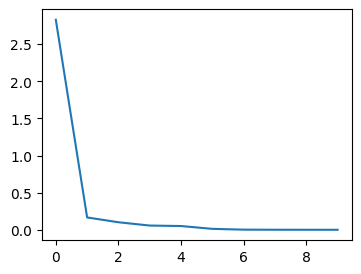

In [40]:
plt.figure(figsize=(4, 3))
plt.plot([l.item() for l in loss_history])

Text(0, 0.5, 'ntp accuracy')

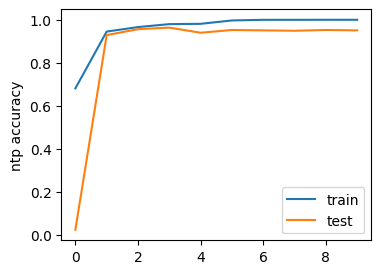

In [43]:
plt.figure(figsize=(4, 3))
plt.plot(train_acc_history, label='train')
plt.plot(test_acc_history, label='test')
plt.legend()
plt.ylabel('ntp accuracy')

## Generation with Finetuned Model

### test data

In [44]:
samplegen_test_hfds = hfds_news_sampled['test'][:6]
gen_texts = generate_from_prompt(samplegen_test_hfds, suffix_prompt='')
for i, t in enumerate(gen_texts):
    print(f'[{i}] gen_text : \n' + t.replace('<|reserved_200017|>', '').replace('<|return|>', ''))
    print(f'[{i}] gt topic : ', samplegen_test_hfds['topic'][i])
    print(100 * '=')

[0] gen_text : 
<|channel|>category<|message|>bussiness
[0] gt topic :  NATION
[1] gen_text : 
<|channel|>analysis<|message|>The user asks to provide the category of the news. The news is about a U.S. politician, Texas AG, about a lawsuit involving him and requests for records from a group. This is political. Category likely "polictics" or "world". But we have categories typically: entertainment, sports, business, politics, technology, world. Since it's about US politics, category is "polictics". The user states: "カテゴリ名のみ答えてそれ以外は出力しないでください。" So we need to output exactly that one category name: politics.<|end|><|start|>assistant<|channel|>final<|message|>politics
[1] gt topic :  NATION_EN
[2] gen_text : 
<|channel|>category:world
[2] gt topic :  WORLD
[3] gen_text : 
<|channel|>analysis<|message|>The user is asking for categories for a specific news item. The news refers to a company (Williams-Sonoma) violating FTC's 'Made in USA' order. This seems to be a business news item about enfor

In [45]:
samplegen_test_hfds = hfds_news_sampled['test'][:6]
gen_texts = generate_from_prompt(samplegen_test_hfds, suffix_prompt='<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>')
for i, t in enumerate(gen_texts):
    print(f'[{i}] gen_text : \n' + t.replace('<|reserved_200017|>', '').replace('<|return|>', ''))
    print(f'[{i}] gt topic : ', samplegen_test_hfds['topic'][i])
    print(100 * '=')

[0] gen_text : 
bussiness
[0] gt topic :  NATION
[1] gen_text : 
nation en>
[1] gt topic :  NATION_EN
[2] gen_text : 
technology
[2] gt topic :  WORLD
[3] gen_text : 
technology
[3] gt topic :  BUSSINESS_EN
[4] gen_text : 
technology
[4] gt topic :  ENTERTAINMENT
[5] gen_text : 
entertainment
[5] gt topic :  ENTERTAINMENT


### train data

In [46]:
samplegen_test_hfds = hfds_news_sampled['train'][:6]
gen_texts = generate_from_prompt(samplegen_test_hfds, suffix_prompt='')
for i, t in enumerate(gen_texts):
    print(f'[{i}] gen_text : \n' + t.replace('<|reserved_200017|>', '').replace('<|return|>', ''))
    print(f'[{i}] gt topic : ', samplegen_test_hfds['topic'][i])
    print(100 * '=')

[0] gen_text : 
<|channel|>analysis<|message|>The user asks to identify the category of this news item. We need to read the content: "元フジ菊間千乃弁護士に...日本保守党の元候補が猛反論 選挙妨害の私見に「私の気持ちがわかるか」 (日刊スポーツ) - Yahoo!ニュース"

It seems about politics/political rumors. Category: politics. The user specifically wants only the category name. So output: "entertainment" no that is other. This is politics category.<|end|><|start|>assistant<|channel|>final<|message|>polictics
[0] gt topic :  ENTERTAINMENT
[1] gen_text : 
<|channel|>analysis<|message|>We need categories: This is sports news. Category: sports.<|end|><|start|>assistant<|channel|>final<|message|>Sports
[1] gt topic :  SPORTS
[2] gen_text : 
<|channel|>analysis<|message|>The user gave a text: “以下のニュースのカテゴリを教えてください。カテゴリ名のみ答えてそれ以外は出力しないでください。 ニュース：<....>”

We need to identify the category of the news. The news seems to be about rankings of ramen shops. It's likely a consumer/entertainment news category. In Yahoo!ニュース categories, this might be "Entertai

In [47]:
samplegen_test_hfds = hfds_news_sampled['train'][:6]
gen_texts = generate_from_prompt(samplegen_test_hfds, suffix_prompt='<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>')
for i, t in enumerate(gen_texts):
    print(f'[{i}] gen_text : \n' + t.replace('<|reserved_200017|>', '').replace('<|return|>', ''))
    print(f'[{i}] gt topic : ', samplegen_test_hfds['topic'][i])
    print(100 * '=')

[0] gen_text : 
sports
[0] gt topic :  ENTERTAINMENT
[1] gen_text : 
sports
[1] gt topic :  SPORTS
[2] gen_text : 
entertainment
[2] gt topic :  ENTERTAINMENT
[3] gen_text : 
entertainment
[3] gt topic :  ENTERTAINMENT
[4] gen_text : 
nation
[4] gt topic :  NATION
[5] gen_text : 
polictics en
[5] gt topic :  POLICTICS_EN


---

GPU memory ~ 19GB (batch size 4)